# Campaign for selling personal Loan

1. Read the column description and ensure you understand each attribute well
2. Study the data distribution in each attribute, share your findings. (5 points)
3. Get the target column distribution. Your comments (5 points)
4. Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)
5. Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer
   buying personal loans (25 points)
6. Print the confusion matrix for all the above models (10 points)
7. Give your reasoning on which is the best model in this case and why it performs better? (10 points)

In [1]:
import warnings 
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import model_selection
from sklearn import metrics
from sklearn.decomposition import PCA
from scipy.stats import zscore
from matplotlib import pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve

In [3]:
bank_df = pd.read_csv("Bank_Personal_Loan_Modelling.csv")

1. Read the column description and ensure you understand each attribute well
2. Study the data distribution in each attribute, share your findings. (5 points)

In [4]:
bank_df.shape

(5000, 14)

5000 Data ( Row ) and 14 attribute ( Columns ) avilable in pandas table

In [5]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [6]:
bank_df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1



There are total 14 columns and 5000 dataset. 13 columns are integer data type and 1 colums float data type. All data set no null values. 

The description of the each attribute  

   1.  ID         :  The Variable ID does not provide any information in our model.It is representing only persons customer ID.
   
   2.  Age        :  Age of customer ID and It will help us to predict our modal. The variables here can be classified as 
                    independent variable.
                    
   3.  Experience :  Customer Experience in his Field. The variables here can be classified as independent variable.
   
   4.  Income     :  Customer Income and it is very importat in our model.The variables here can be classified as independent 
                    variable.
                    
   5.  ZipCode    :  Customer current address. It may not give much  information to our model. The variables here can be
                    classified as independent variable.
                    
   6.  Family     :  Customer family member. The variables here can be classified as independent variable.
   
   7.  CCAvg      :  Customer Average credit card spending. The variables here can be classified as independent variable.
   
   8.  Education  :  Customer Education and it is Ordinal Categorical independent Variable.
   
   9.  Mortgage   :  Value of House. The variables here can be classified as independent variable.
   
   10. Personal Loan      : Whether customere accepted personal loan or not. It is binary category. This is our target
                            ( dependent ) variable.
                            
   11. Securities Account : Whether customer have a securities account with the bank ?. It is binary category and independant                             variable.
                            
   12. CDAccount          : Whether the customer have a certificate of deposit (CD) account with the bank ? It is binary 
                            category and independant variable.
                            
   13. Online             : Whether the customer use internet banking facilities ?. It is binary category and independant
                            variable.
   14. CreditCard         : Whether the the customer use a credit card?. It is binary category and independant  variable.

3. Get the target column distribution. Your comments (5 points)
         Personal Loan      : Whether customere accepted personal loan or not. It is binary category. This is our target
                            ( dependent ) variable.

*****Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median)

In [7]:
# Check the Null values
bank_df.isnull().any()

ID                    False
Age                   False
Experience            False
Income                False
ZIP Code              False
Family                False
CCAvg                 False
Education             False
Mortgage              False
Personal Loan         False
Securities Account    False
CD Account            False
Online                False
CreditCard            False
dtype: bool

In [8]:
bank_df[pd.isnull(bank_df).any(axis=1)]

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard


In [9]:
#Observing Statics
bank_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


Observation :
1. ID and Zipcode not going to use this model.
2. There are negative records in Experience. Before processing the data we must correct it.

In [10]:
#Check How many negative experience customer
bank_df[bank_df['Experience'] < 0]['Experience'].count()

52

        1. There are 52 nagetive records in Experience columns.
        2. We can do median experience of same age group to repalce the negative experience.

In [11]:
Exp_Postive = bank_df.loc[bank_df['Experience'] >0]
Exp_Negative = bank_df.Experience < 0 
ID_Negative = bank_df.loc[Exp_Negative]['ID'].tolist() 

In [12]:
for id in ID_Negative:
    Age =  bank_df.loc[np.where( bank_df['ID']==id)]["Age"].tolist()[0]
    Edu =  bank_df.loc[np.where( bank_df['ID']==id)]["Education"].tolist()[0]
    df = Exp_Postive[(Exp_Postive.Age == Age) & (Exp_Postive.Education == Edu)]
    exp = df['Experience'].median()
    bank_df.loc[bank_df.loc[np.where(bank_df['ID']==id)].index, 'Experience'] = exp

In [13]:
#Check How many negative experience customer
bank_df[bank_df['Experience'] < 0]['Experience'].count()

0

In [14]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            4971 non-null float64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(2), int64(12)
memory usage: 547.0 KB


After replacing nagative values, found 29 records "NaN" valuse may e because of same age group not found.

In [15]:
bank_df[pd.isnull(bank_df).any(axis=1)]

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
226,227,24,NaN,39,94085,2,1.70,2,0,0,0,0,0,0
315,316,24,NaN,51,90630,3,0.30,3,0,0,0,0,1,0
524,525,24,NaN,75,93014,4,0.20,1,0,0,0,0,1,0
583,584,24,NaN,38,95045,2,1.70,2,0,0,0,0,1,0
597,598,24,NaN,125,92835,2,7.20,1,0,0,1,0,0,1
670,671,23,NaN,61,92374,4,2.60,1,239,0,0,0,1,0
686,687,24,NaN,38,92612,4,0.60,2,0,0,0,0,1,0
793,794,24,NaN,150,94720,2,2.00,1,0,0,0,0,1,0
889,890,24,NaN,82,91103,2,1.60,3,0,0,0,0,1,1
909,910,23,NaN,149,91709,1,6.33,1,305,0,0,0,0,1


So, we will have to see how to replace those missing values with some estimated values (median) *

In [16]:
bank_df["Experience"].fillna(0,inplace=True)

In [17]:
bank_df['Experience']=bank_df['Experience'].replace(0,bank_df['Experience'].median()) 

In [18]:
bank_df[pd.isnull(bank_df).any(axis=1)]

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard


In [19]:
#Observing Statics
bank_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.505800,11.081720,1.0,11.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [20]:
bank_df.groupby(["Personal Loan"]).count()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
Personal Loan,,,,,,,,,,,,,
0,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520
1,480,480,480,480,480,480,480,480,480,480,480,480,480


Observe the association of each independent variable with target variable 

In [21]:
bank_df.corr()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,1.000000,-0.008473,-0.003238,-0.017695,0.013432,-0.016797,-0.024675,0.021463,-0.013920,-0.024801,-0.016972,-0.006909,-0.002528,0.017028
Age,-0.008473,1.000000,0.964643,-0.055269,-0.029216,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,-0.003238,0.964643,1.000000,-0.051171,-0.030141,-0.042303,-0.048059,0.021879,-0.016777,-0.010893,0.002359,0.004565,0.008599,0.004614
Income,-0.017695,-0.055269,-0.051171,1.000000,-0.016410,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIP Code,0.013432,-0.029216,-0.030141,-0.016410,1.000000,0.011778,-0.004061,-0.017377,0.007383,0.000107,0.004704,0.019972,0.016990,0.007691
Family,-0.016797,-0.046418,-0.042303,-0.157501,0.011778,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.024675,-0.052012,-0.048059,0.645984,-0.004061,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.021463,0.041334,0.021879,-0.187524,-0.017377,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.013920,-0.012539,-0.016777,0.206806,0.007383,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal Loan,-0.024801,-0.007726,-0.010893,0.502462,0.000107,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802


In [22]:
bank_df.apply(lambda x: len(x.unique()))

ID                    5000
Age                     45
Experience              43
Income                 162
ZIP Code               467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
Personal Loan            2
Securities Account       2
CD Account               2
Online                   2
CreditCard               2
dtype: int64

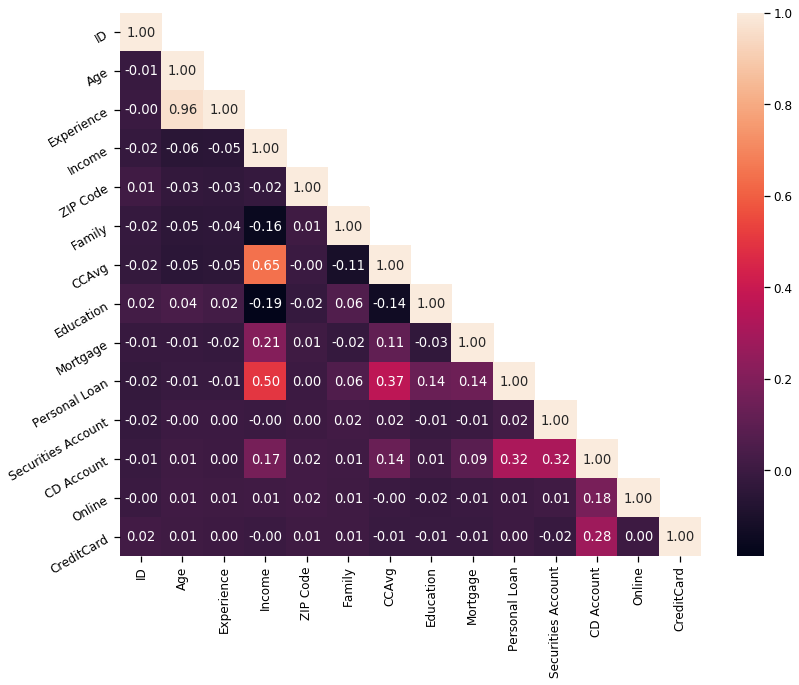

In [23]:
# Correlation with heat map
import matplotlib.pyplot as plt
import seaborn as sns
corr =bank_df.corr()
sns.set_context("notebook", font_scale=1.1, rc={"lines.linewidth": 1.5})
plt.figure(figsize=(13,10))
# create a mask so we only see the correlation values once
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, 1)] = True
a = sns.heatmap(corr,mask=mask, annot=True, fmt='.2f')
rotx = a.set_xticklabels(a.get_xticklabels(), rotation=90)
roty = a.set_yticklabels(a.get_yticklabels(), rotation=30)

Observation :
      1. Income and CCAvg is ascetically correlated.
      2. Age and Experience is highly correlated

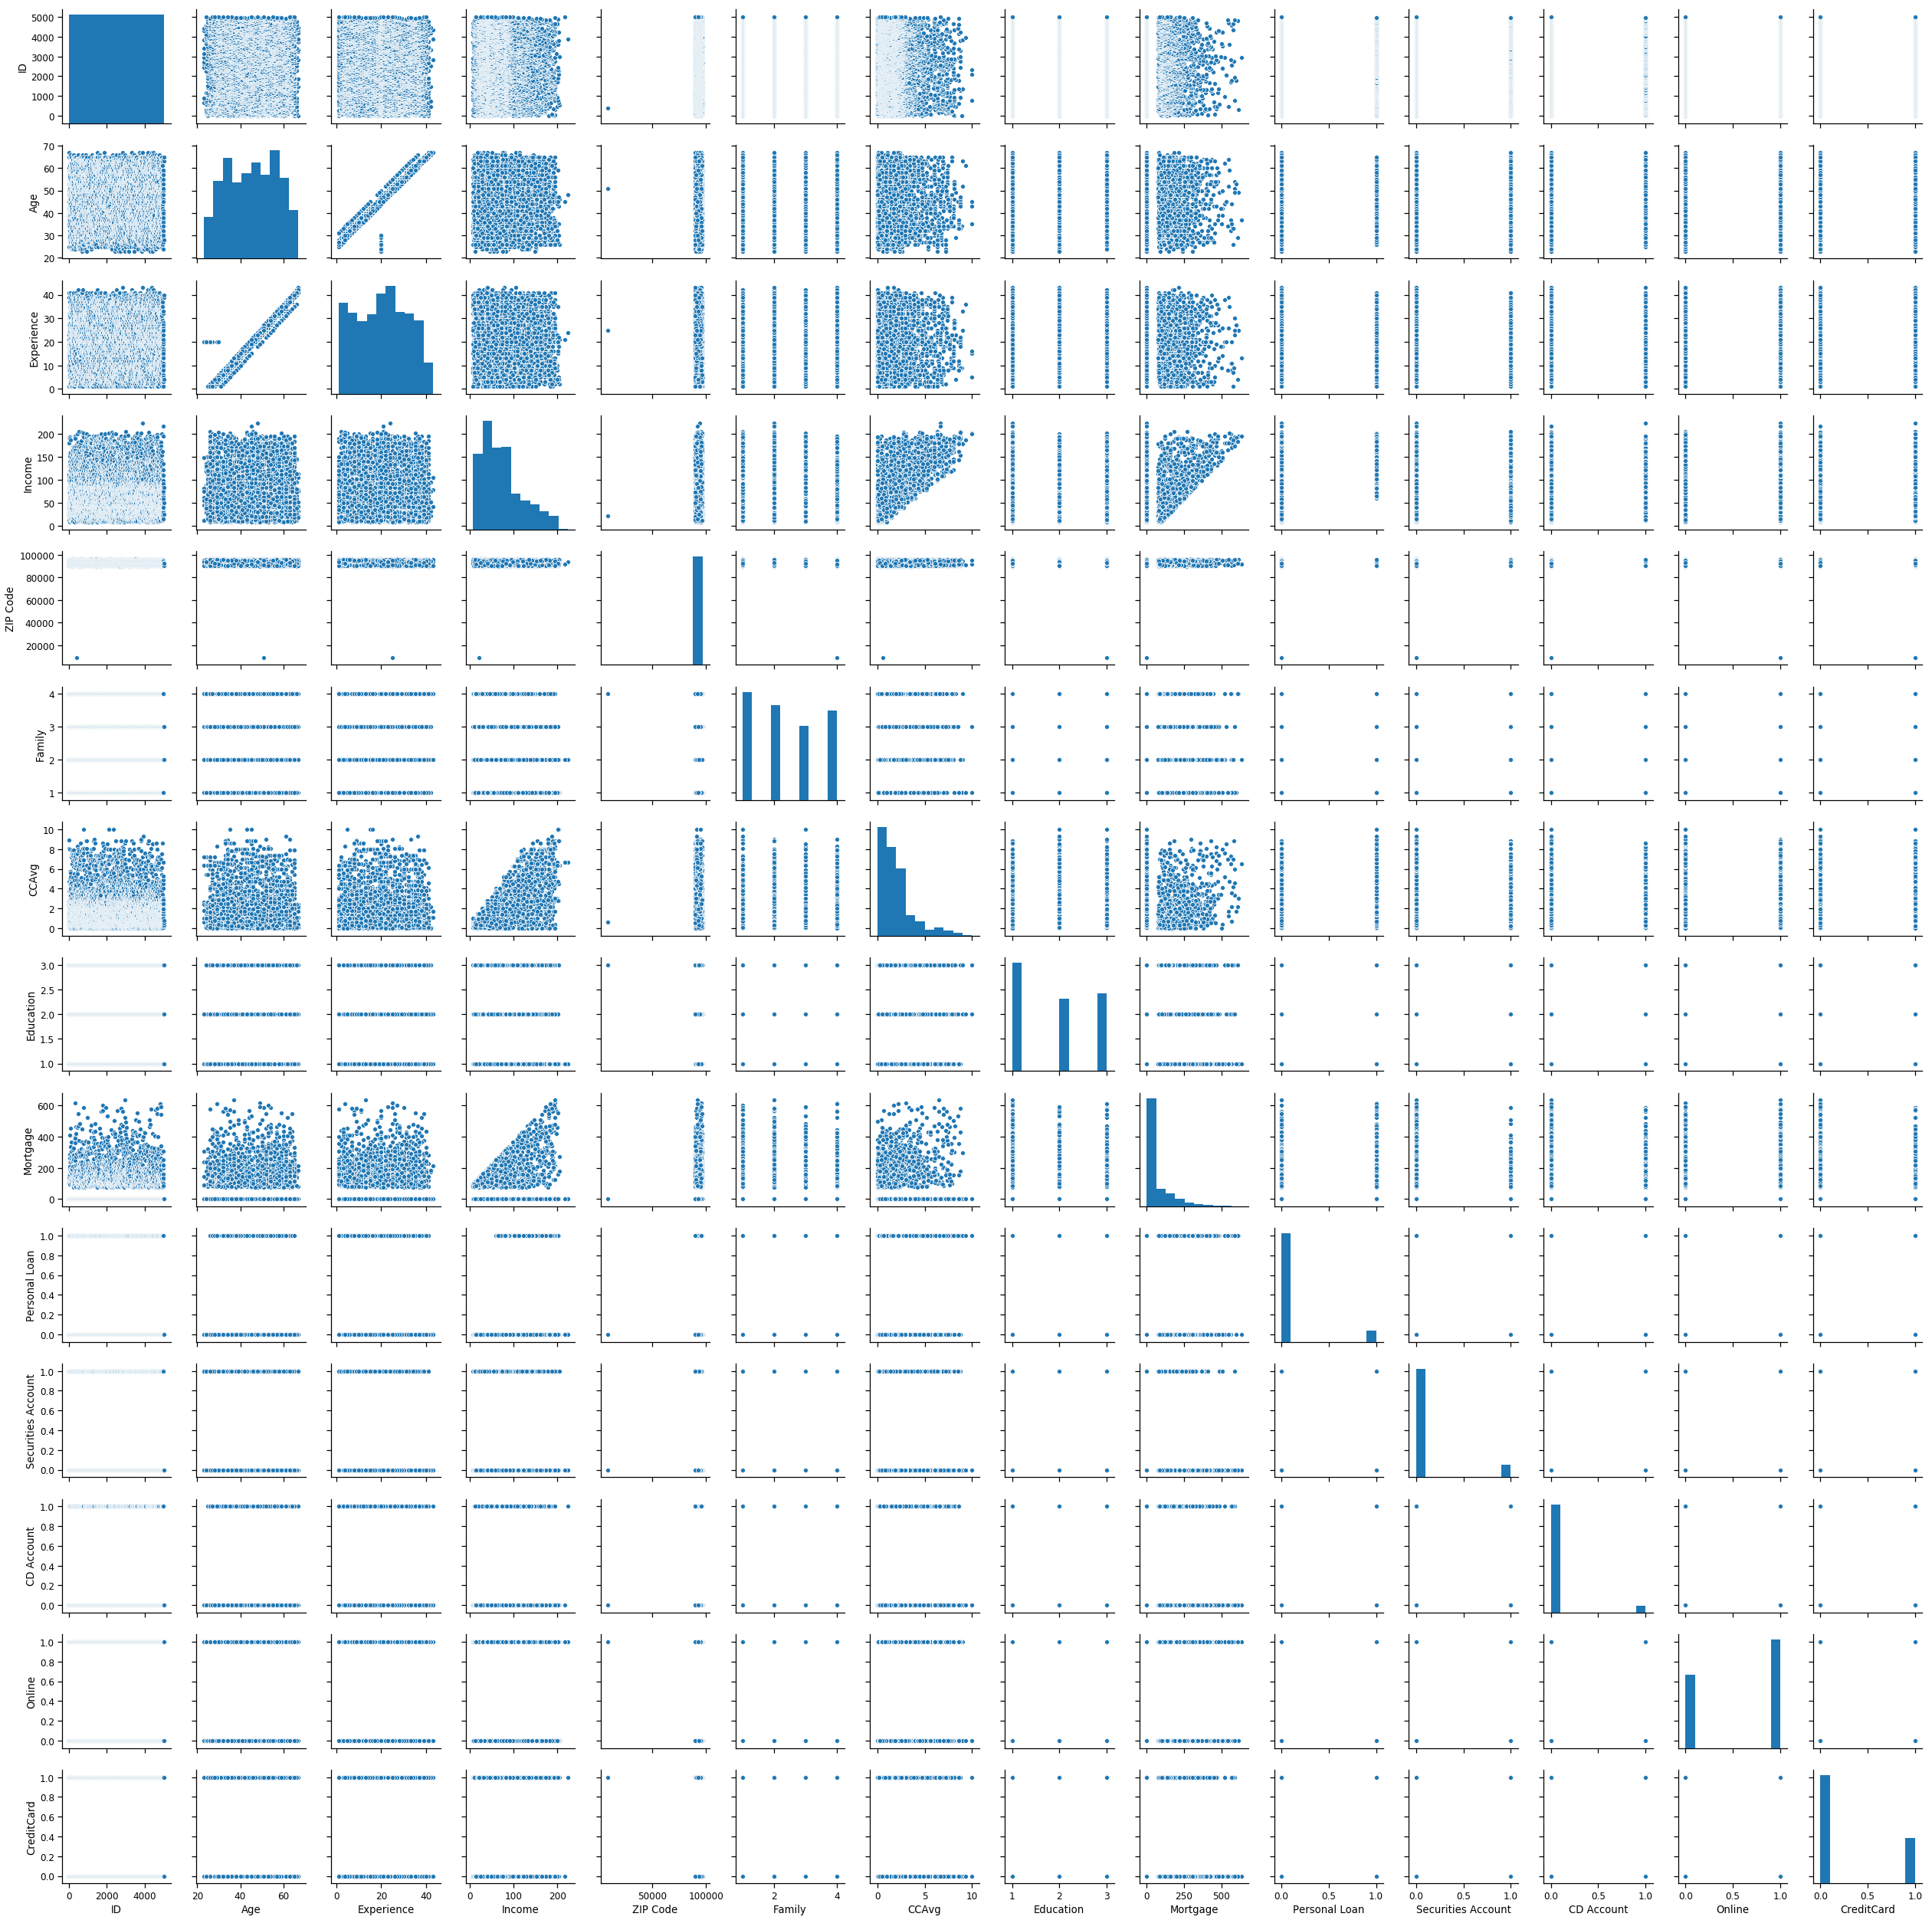

In [24]:
sns.pairplot(bank_df)

In [25]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null float64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(2), int64(12)
memory usage: 547.0 KB


C:\Users\apichu\Anaconda3\lib\site-packages\seaborn\axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


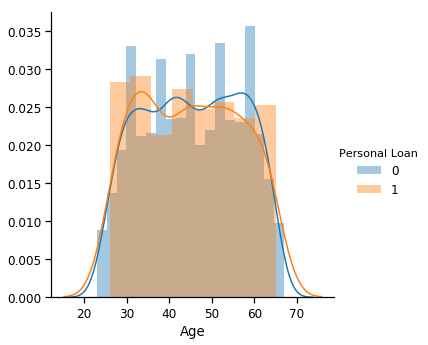

In [26]:
sns.FacetGrid(bank_df,hue="Personal Loan", size=5).map(sns.distplot,"Age").add_legend()

Observation : Majority of personal loan customer falls between 25 years to 65 years. 

C:\Users\apichu\Anaconda3\lib\site-packages\seaborn\axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


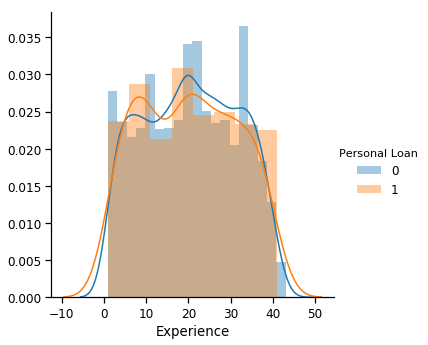

In [27]:
sns.FacetGrid(bank_df,hue="Personal Loan", size=5).map(sns.distplot,"Experience").add_legend()

Experience is normally distributed. Hence mean is equal to median

C:\Users\apichu\Anaconda3\lib\site-packages\seaborn\axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


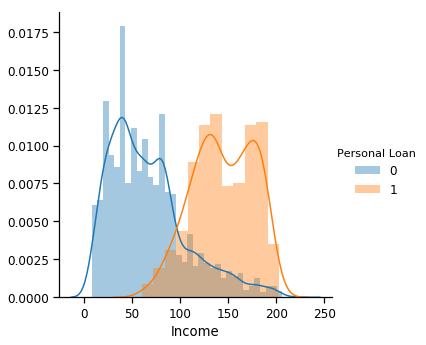

In [28]:
sns.FacetGrid(bank_df,hue="Personal Loan", size=5).map(sns.distplot,"Income").add_legend()

Observation : Majority of personal loan customer having salray more than 50K. Hence mean is greater than median

C:\Users\apichu\Anaconda3\lib\site-packages\seaborn\axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


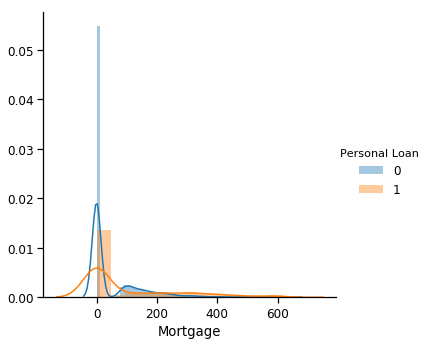

In [29]:
sns.FacetGrid(bank_df,hue="Personal Loan", size=5).map(sns.distplot,"Mortgage").add_legend()

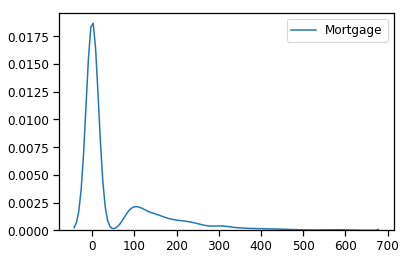

In [30]:
sns.kdeplot(bank_df.Mortgage)

Observation : Mortgage 75% of the individuals have a mortgage of less than 50K. However the max value is 635K

C:\Users\apichu\Anaconda3\lib\site-packages\seaborn\axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


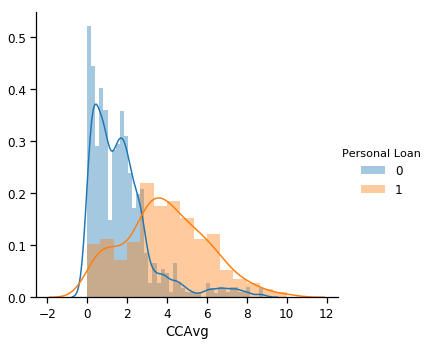

In [31]:
sns.FacetGrid(bank_df,hue="Personal Loan", size=5).map(sns.distplot,"CCAvg").add_legend()

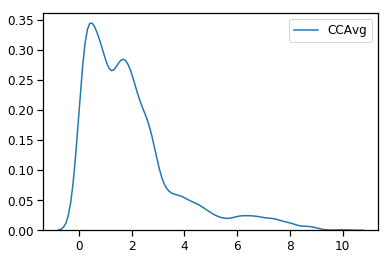

In [32]:
sns.kdeplot(bank_df.CCAvg)

Observation : CCAvg is also a positively skewed variable and average spending is between 0K to 10K and majority spends less than 2.5K

C:\Users\apichu\Anaconda3\lib\site-packages\seaborn\axisgrid.py:230: UserWarning: The `size` paramter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


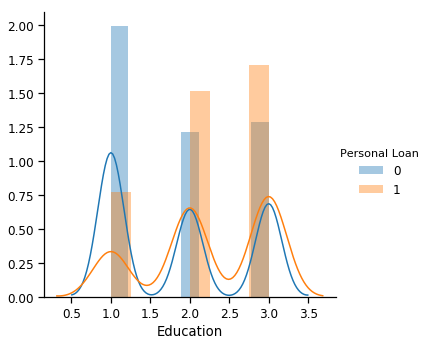

In [33]:
sns.FacetGrid(bank_df,hue="Personal Loan", size=5).map(sns.distplot,"Education").add_legend()

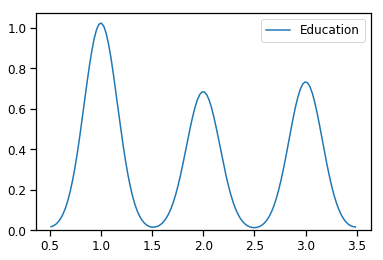

In [34]:
sns.kdeplot(bank_df.Education)

Observation : Personal loan increased with Higher the education

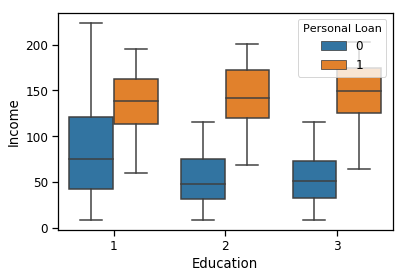

In [35]:
sns.boxplot(x='Education',y='Income',hue='Personal Loan',data=bank_df)           

Observation :Customers whose education level is 1 is having more income. But customers who has taken the personal loan have the same income levels

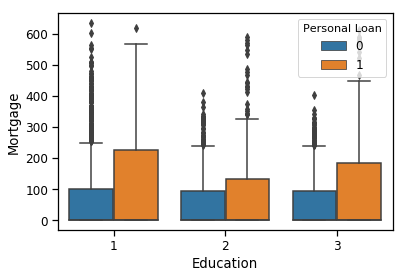

In [36]:
sns.boxplot(x="Education", y='Mortgage', hue="Personal Loan", data=bank_df)

Observation :Customers who is having  personal loan will have more Mortgage.

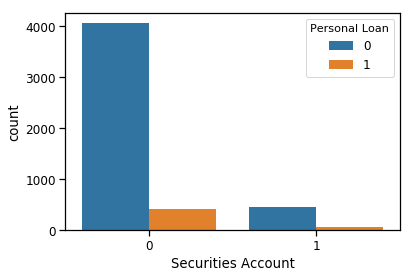

In [37]:
sns.countplot(x="Securities Account", data=bank_df,hue="Personal Loan")

Observation : Majority of customers who is not haveing  securities account, They dont have personal loan.

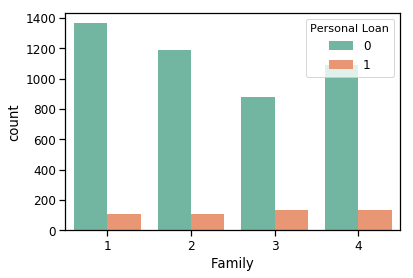

In [38]:
sns.countplot(x='Family',data=bank_df,hue='Personal Loan',palette='Set2')

Observation: Family size does not have any impact in personal loan.

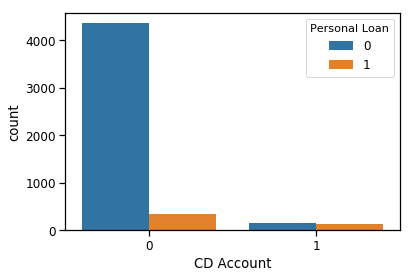

In [39]:
sns.countplot(x='CD Account',data=bank_df,hue='Personal Loan')

Observation: All customer who has CD account has loan as well. The majority Customers who does not have CD account , does not have loan as well. 

Text(0, 0.5, 'Age')

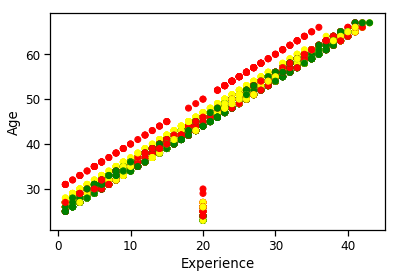

In [40]:
fig, ax = plt.subplots()
colors = {1:'green',2:'yellow',3:'red'}
ax.scatter(bank_df['Experience'],bank_df['Age'],c=bank_df['Education'].apply(lambda x:colors[x]))
plt.xlabel('Experience')
plt.ylabel('Age')

Observation : As experience increase age also increases. Also the colors show the education level. 

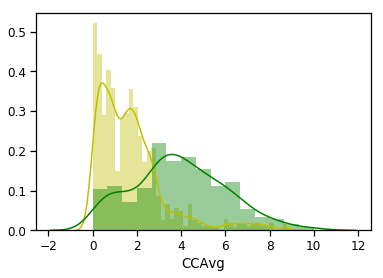

In [41]:
sns.distplot( bank_df[bank_df["Personal Loan"] == 0]['CCAvg'], color = 'y')
sns.distplot( bank_df[bank_df["Personal Loan"] == 1]['CCAvg'], color = 'g')

In [42]:
print('Credit card spending of Non-Loan customers: ',bank_df[bank_df["Personal Loan"] == 0]['CCAvg'].median()*1000)
print('Credit card spending of Loan customers    : ',bank_df[bank_df["Personal Loan"] == 1]['CCAvg'].median()*1000)

Credit card spending of Non-Loan customers:  1400.0
Credit card spending of Loan customers    :  3800.0


Observation : The coustomer who is spending more money spend in credit card having higher  personal loan. 

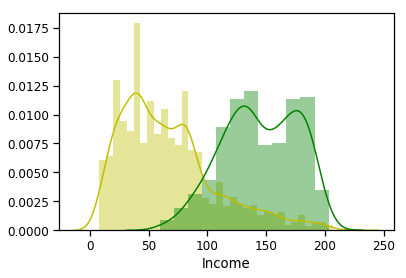

In [43]:
sns.distplot( bank_df[bank_df["Personal Loan"] == 0]['Income'], color = 'y')
sns.distplot( bank_df[bank_df["Personal Loan"] == 1]['Income'], color = 'g')

In [44]:
print('Income of Non-Loan customers: ',bank_df[bank_df["Personal Loan"] == 0]['Income'].median()*1000)
print('Income Loan customers    : ',bank_df[bank_df["Personal Loan"] == 1]['Income'].median()*1000)

Income of Non-Loan customers:  59000.0
Income Loan customers    :  142500.0


Observation : The coustomer who is spending more income having higher personal loan. 

# Split the data into training and test set in the ratio of 70:30 respectively

The variable ID and ZipCode does not add any interesting information  

In [45]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null float64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(2), int64(12)
memory usage: 547.0 KB


In [46]:
X =  bank_df.drop(["Personal Loan","ID","ZIP Code"], axis=1)
y =  bank_df["Personal Loan"]

C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


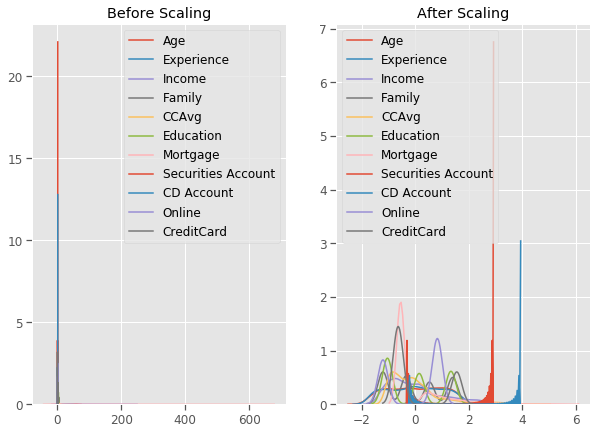

In [47]:
from sklearn import preprocessing
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
matplotlib.style.use('ggplot')

scaler = preprocessing.StandardScaler()
scaled_df = scaler.fit_transform(X)
scaled_df = pd.DataFrame(scaled_df, columns=['Age','Experience', 'Income', 'Family','CCAvg','Education','Mortgage','Securities Account','CD Account','Online','CreditCard'])
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 7))


ax1.set_title('Before Scaling')
sns.kdeplot(X['Age'], ax=ax1)
sns.kdeplot(X['Experience'], ax=ax1)
sns.kdeplot(X['Income'], ax=ax1)
sns.kdeplot(X['Family'], ax=ax1)
sns.kdeplot(X['CCAvg'], ax=ax1)
sns.kdeplot(X['Education'], ax=ax1)
sns.kdeplot(X['Mortgage'], ax=ax1)
sns.kdeplot(X['Securities Account'], ax=ax1)
sns.kdeplot(X['CD Account'], ax=ax1)
sns.kdeplot(X['Online'], ax=ax1)
sns.kdeplot(X['CreditCard'], ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(scaled_df['Age'], ax=ax2)
sns.kdeplot(scaled_df['Experience'], ax=ax2)
sns.kdeplot(scaled_df['Income'], ax=ax2)
sns.kdeplot(scaled_df['Family'], ax=ax2)
sns.kdeplot(scaled_df['CCAvg'], ax=ax2)
sns.kdeplot(scaled_df['Education'], ax=ax2)
sns.kdeplot(scaled_df['Mortgage'], ax=ax2)
sns.kdeplot(scaled_df['Securities Account'], ax=ax2)
sns.kdeplot(scaled_df['CD Account'], ax=ax2)
sns.kdeplot(scaled_df['Online'], ax=ax2)
sns.kdeplot(scaled_df['CreditCard'], ax=ax2)
plt.show()


# Logistic Regression 

In [48]:
X=scaled_df
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [49]:
model = LogisticRegression()

In [50]:
model.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)

In [51]:
y_predict = model.predict(X_test)

In [52]:
accuracy=metrics.accuracy_score(y_test,y_predict)
print(accuracy)

0.9546666666666667


In [53]:
cm=metrics.confusion_matrix(y_test,y_predict)
print(cm)

[[1343   19]
 [  49   89]]


In [54]:
sum(y_test)

138

In [55]:
from sklearn.metrics import roc_curve, auc

In [56]:
y_predictProb = model.predict_proba(X_test)

In [57]:
fpr, tpr, thresholds = roc_curve(y_test, y_predictProb[::,1])

In [58]:
roc_auc = auc(fpr, tpr)
roc_auc

0.9651248164464024

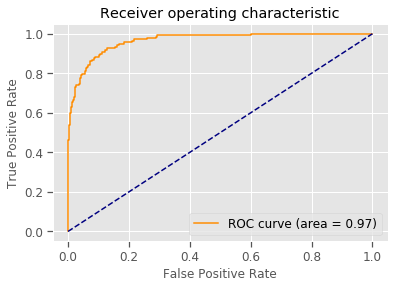

In [59]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

In [83]:
optimalTh=0
optimalF1=0
for th in thresholds:
    preds = np.where(model.predict_proba(X_train)[:,1] > th, 1, 0)
    tempF1= f1_score(y_train, preds)
    if (tempF1 > optimalF1):
        optimalF1 =tempF1
        OptimalTh=th
        
preds = np.where(model.predict_proba(X_train)[:,1] > OptimalTh, 1, 0)

raw_data = { 'OptimalTh' : [OptimalTh],'Accuracy' : [accuracy_score(y_train, preds)],
              'Recall' : [ recall_score(y_train, preds)],'Precision' : [precision_score(y_train, preds)], 
              'F1Score' :  f1_score(y_train, preds)}

Results = pd.DataFrame(raw_data,index=["Logistic Regression"])


C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: Unde

In [84]:
Results

,OptimalTh,Accuracy,Recall,Precision,F1Score
Logistic Regression,0.364687,0.949143,0.695906,0.762821,0.727829


# KNN

In [85]:
# Call Nearest Neighbour algorithm
KNN = KNeighborsClassifier(n_neighbors= 21)
KNN.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=21, p=2,
           weights='uniform')

In [86]:
y_predict = KNN.predict(X_test)

In [87]:
accuracy=metrics.accuracy_score(y_test,y_predict)
print(accuracy)

0.9493333333333334


In [88]:
cm=metrics.confusion_matrix(y_test,y_predict)
print(cm)

[[1353    9]
 [  67   71]]


In [89]:
from sklearn.metrics import roc_curve, auc

In [90]:
y_predictProb = KNN.predict_proba(X_test)

In [91]:
fpr, tpr, thresholds = roc_curve(y_test, y_predictProb[::,1])

In [92]:
roc_auc = auc(fpr, tpr)
roc_auc

0.9653349720147268

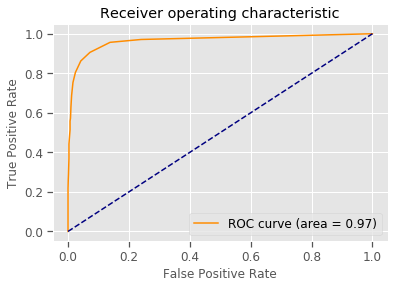

In [93]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

In [94]:
optimalTh=0
optimalF1=0
for th in thresholds:
    preds = np.where(KNN.predict_proba(X_train)[:,1] > th, 1, 0)
    tempF1= f1_score(y_train, preds)
    if (tempF1 > optimalF1):
        optimalF1 =tempF1
        OptimalTh=th
        
preds = np.where(KNN.predict_proba(X_train)[:,1] > OptimalTh, 1, 0)


raw_data1 = { 'OptimalTh' : [OptimalTh],'Accuracy' : [accuracy_score(y_train, preds)],
              'Recall' : [ recall_score(y_train, preds)],'Precision' : [precision_score(y_train, preds)], 
              'F1Score' :  f1_score(y_train, preds)}

Results1 = pd.DataFrame(raw_data1,index=["KNN"])



C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


In [95]:
Results1

,OptimalTh,Accuracy,Recall,Precision,F1Score
KNN,0.190476,0.963143,0.836257,0.796657,0.815977


In [97]:
F_Result = Results.append(Results1,ignore_index=False)
F_Result

,OptimalTh,Accuracy,Recall,Precision,F1Score
Logistic Regression,0.364687,0.949143,0.695906,0.762821,0.727829
KNN,0.190476,0.963143,0.836257,0.796657,0.815977


# Fit NaiveBayes Model

In [98]:
NBM = GaussianNB()
NBM.fit(X_train, y_train)
y_predict = NBM.predict(X_test)
accuracy=metrics.accuracy_score(y_test,y_predict)
print(accuracy)

0.8793333333333333


In [99]:
cm=metrics.confusion_matrix(y_test,y_predict)
print(cm)

[[1237  125]
 [  56   82]]


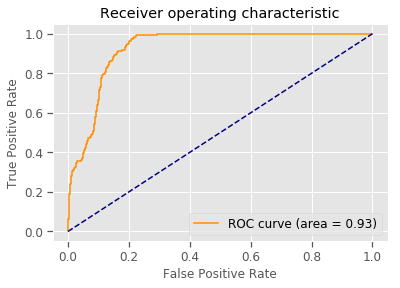

In [100]:
from sklearn.metrics import roc_curve, auc
y_predictProb = NBM.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_predictProb[::,1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

In [103]:
optimalTh=0
optimalF1=0
for th in thresholds:
    preds = np.where(NBM.predict_proba(X_train)[:,1] > th, 1, 0)
    tempF1= f1_score(y_train, preds)
    if (tempF1 > optimalF1):
        optimalF1 =tempF1
        OptimalTh=th
        
preds = np.where(NBM.predict_proba(X_train)[:,1] > OptimalTh, 1, 0)
raw_data2 = { 'OptimalTh' : [OptimalTh],'Accuracy' : [accuracy_score(y_train, preds)],
              'Recall' : [ recall_score(y_train, preds)],'Precision' : [precision_score(y_train, preds)], 
              'F1Score' :  f1_score(y_train, preds)}

Results2 = pd.DataFrame(raw_data2,index=["Naïve Bayes"])


C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


In [104]:
F_Result =F_Result.append(Results2,ignore_index=False)

# RandomForestClassifier algorithm

In [129]:
RFM = RandomForestClassifier(max_depth=4, random_state=0)

In [130]:
RFM.fit(X_train, y_train)
y_predict = RFM.predict(X_test)
accuracy=metrics.accuracy_score(y_test,y_predict)
print(accuracy)

0.9606666666666667


In [131]:
cm=metrics.confusion_matrix(y_test,y_predict)
print(cm)

[[1360    2]
 [  57   81]]


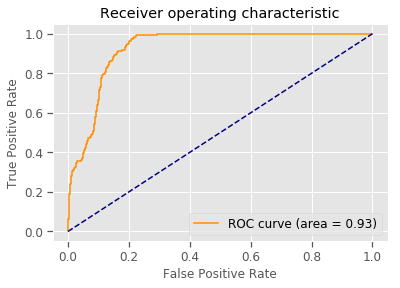

In [132]:
from sklearn.metrics import roc_curve, auc
y_predictProb = NBM.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_predictProb[::,1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

In [136]:
optimalTh=0
optimalF1=0
for th in thresholds:
    preds = np.where(RFM.predict_proba(X_train)[:,1] > th, 1, 0)
    tempF1= f1_score(y_train, preds)
    if (tempF1 > optimalF1):
        optimalF1 =tempF1
        OptimalTh=th
        
preds = np.where(RFM.predict_proba(X_train)[:,1] > OptimalTh, 1, 0)
raw_data3 = { 'OptimalTh' : [OptimalTh],'Accuracy' : [accuracy_score(y_train, preds)],
              'Recall' : [ recall_score(y_train, preds)],'Precision' : [precision_score(y_train, preds)], 
              'F1Score' :  f1_score(y_train, preds)}

Results3 = pd.DataFrame(raw_data3,index=["RFM"])

C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: Unde

C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\apichu\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


In [137]:
Results3

,OptimalTh,Accuracy,Recall,Precision,F1Score
RFM,0.291366,0.981429,0.909357,0.901449,0.905386


In [138]:
F_Result =F_Result.append(Results3,ignore_index=False)

In [139]:
F_Result

,OptimalTh,Accuracy,Recall,Precision,F1Score
Logistic Regression,0.364687,0.949143,0.695906,0.762821,0.727829
KNN,0.190476,0.963143,0.836257,0.796657,0.815977
Naïve Bayes,0.057707,0.866000,0.807018,0.406480,0.540646
RFM,0.291366,0.981429,0.909357,0.901449,0.905386


LR: 0.951400 (0.005589)
KNN: 0.960600 (0.007645)
NB: 0.883000 (0.011323)
RF: 0.984800 (0.002857)


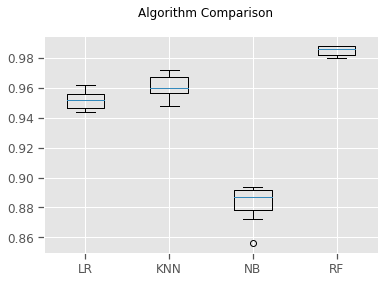

In [128]:
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('NB', GaussianNB()))
models.append(('RF', RandomForestClassifier()))

# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
	kfold = model_selection.KFold(n_splits=10, random_state=7)
	cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

Conclusion

        The aim of the bank is to convert there liability customers into loan customers.
        Four classification algorithms were used in this study. From the above graph,
        it seems like KNN algorithm have the highest accuracy,F1Score compare to Logistic Reg. and KNN and we can choose
        that as our final model.
        Howevere, I done  RandomForestClassifier algorithm to check. I found acuracy level is good compare to other models. 